# 03 用户留存队列分析 (Cohort Retention)

> **目标：** 使用 Cohort Analysis 方法，按月追踪不同批次用户的留存率与复购行为。

**为什么重要：** 留存分析是区分「增长健康」与「烧钱换增长」的核心指标。电商行业中，获得一个新客的成本是留住老客的 5-7 倍。

**分析内容：**
1. 用户首次购买月份（Cohort）定义
2. 逐月留存矩阵
3. 平均复购周期
4. 不同获客渠道/品类的留存差异

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 8)
sns.set_style('whitegrid')

df = pd.read_csv('../data/master_orders_clean.csv')
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

print(f'Loaded: {df.shape[0]:,} rows')

Loaded: 110,840 rows


In [2]:
# Build user-order summary
user_orders = df.groupby(['customer_unique_id', 'order_id']).agg(
    purchase_date=('order_purchase_timestamp', 'min'),
    order_value=('total_payment', 'first'),
    items=('price', 'count'),
).reset_index()

user_orders['purchase_month'] = user_orders['purchase_date'].dt.to_period('M')

# Get first purchase month per user
first_purchase = user_orders.groupby('customer_unique_id')['purchase_month'].min().reset_index()
first_purchase.columns = ['customer_unique_id', 'cohort_month']

# Merge back
user_orders = user_orders.merge(first_purchase, on='customer_unique_id')

# Calculate month offset (0 = cohort month)
user_orders['month_offset'] = (
    user_orders['purchase_month'].dt.year * 12 + user_orders['purchase_month'].dt.month
    - (user_orders['cohort_month'].dt.year * 12 + user_orders['cohort_month'].dt.month)
)

print(f'Total users: {user_orders["customer_unique_id"].nunique():,}')
print(f'Total orders: {user_orders["order_id"].nunique():,}')
print(f'Avg orders per user: {user_orders["order_id"].nunique() / user_orders["customer_unique_id"].nunique():.2f}')
print(f'Cohort range: {user_orders["cohort_month"].min()} → {user_orders["cohort_month"].max()}')

Total users: 93,358
Total orders: 96,478
Avg orders per user: 1.03
Cohort range: 2016-09 → 2018-08


Cohort Retention Matrix (%):
Rows = Cohort Month, Columns = Month Offset
Month 0 = 100% (first purchase month)


month_offset,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,100.0,NaN,NaN,NaN,NaN,NaN,0.4,NaN,NaN,0.4,NaN,0.4,NaN,0.4,NaN,0.4,NaN,0.4,0.8,0.8
2016-12,100.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,100.0,0.3,0.3,0.1,0.4,0.1,0.4,0.1,0.1,NaN,0.4,0.1,0.7,0.4,0.1,0.1,0.3,0.4,0.1,NaN
2017-02,100.0,0.2,0.3,0.1,0.4,0.1,0.2,0.2,0.1,0.2,0.1,0.3,0.1,0.2,0.1,0.1,0.1,0.2,NaN,NaN
2017-03,100.0,0.4,0.4,0.4,0.4,0.2,0.2,0.3,0.3,0.1,0.4,0.1,0.2,0.1,0.2,0.2,0.1,0.1,NaN,NaN
2017-04,100.0,0.6,0.2,0.2,0.3,0.3,0.4,0.3,0.3,0.2,0.3,0.1,0.0,0.0,0.1,0.1,0.1,NaN,NaN,NaN
2017-05,100.0,0.5,0.5,0.3,0.3,0.3,0.4,0.1,0.3,0.3,0.3,0.3,0.2,0.0,0.2,0.2,NaN,NaN,NaN,NaN
2017-06,100.0,0.5,0.4,0.4,0.3,0.4,0.4,0.2,0.1,0.2,0.3,0.4,0.2,0.2,0.2,NaN,NaN,NaN,NaN,NaN


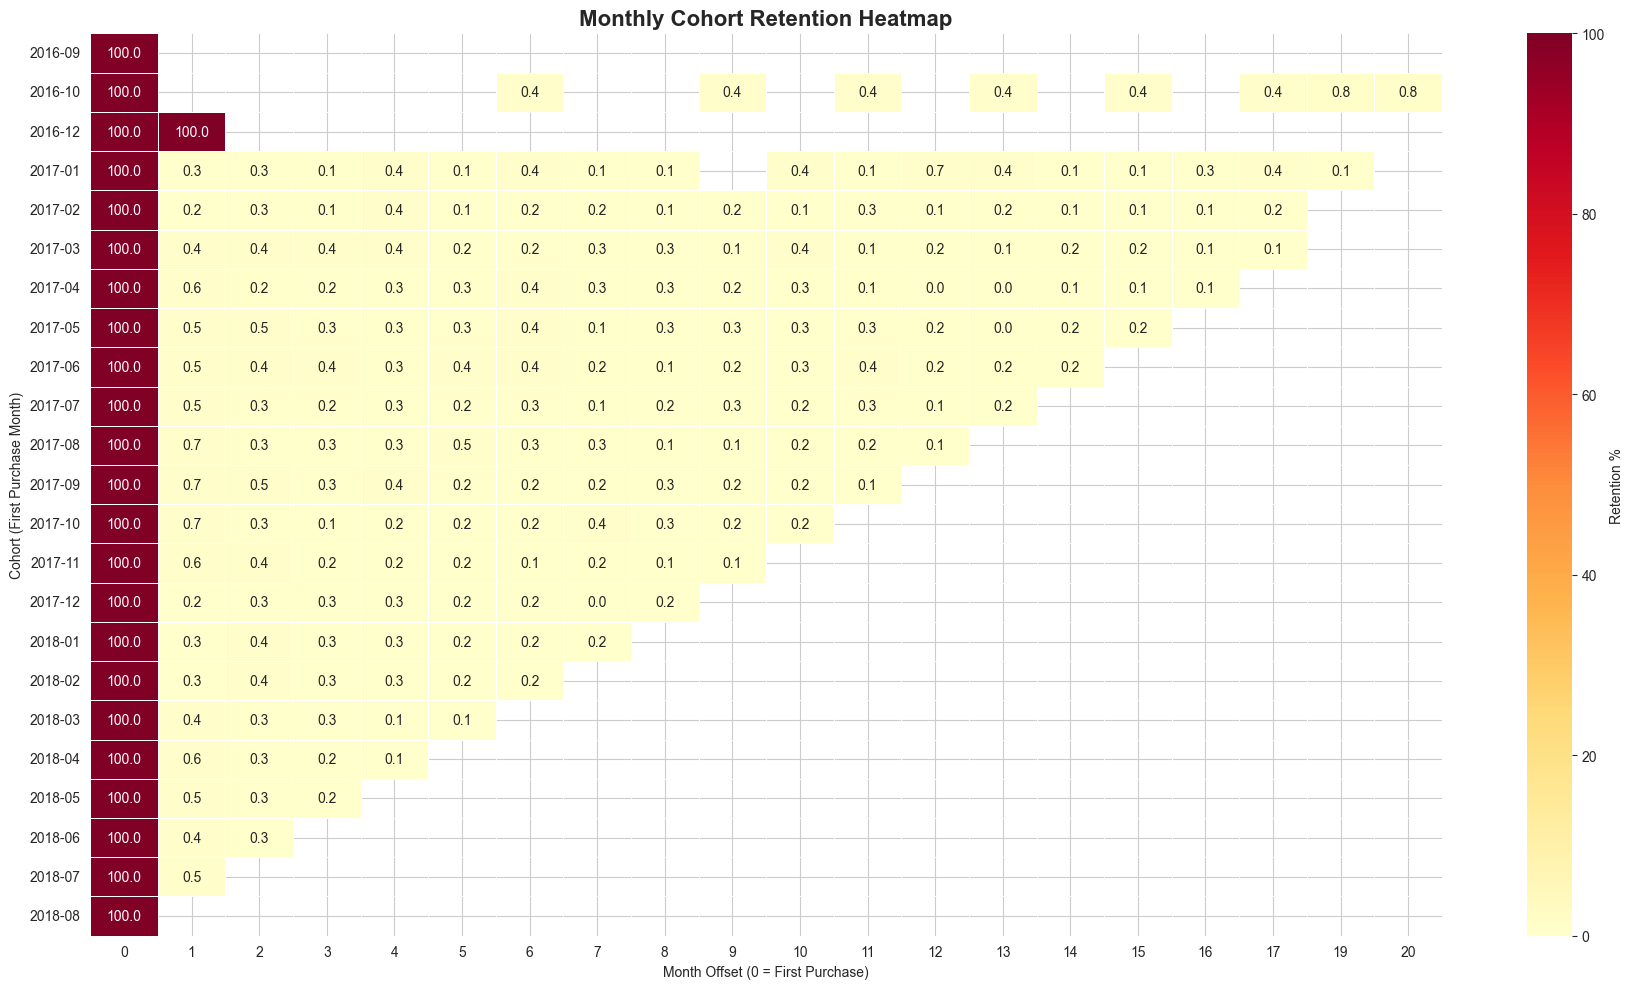

In [3]:
# Build cohort retention matrix
cohort_size = user_orders.groupby('cohort_month')['customer_unique_id'].nunique()

cohort_data = user_orders.groupby(['cohort_month', 'month_offset'])['customer_unique_id'].nunique().reset_index()
cohort_data = cohort_data.merge(cohort_size.reset_index(name='cohort_size'), on='cohort_month')
cohort_data['retention_pct'] = (cohort_data['customer_unique_id'] / cohort_data['cohort_size'] * 100).round(1)

# Pivot to matrix form
retention_matrix = cohort_data.pivot_table(
    index='cohort_month',
    columns='month_offset',
    values='retention_pct'
)

# Display recent cohorts
print(f'Cohort Retention Matrix (%):')
print(f'Rows = Cohort Month, Columns = Month Offset')
print(f'Month 0 = 100% (first purchase month)')
display(retention_matrix.round(1))

# Heatmap
fig, ax = plt.subplots(figsize=(18, 10))
sns.heatmap(retention_matrix, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Retention %'})
ax.set_title('Monthly Cohort Retention Heatmap', fontsize=16, fontweight='bold')
ax.set_xlabel('Month Offset (0 = First Purchase)')
ax.set_ylabel('Cohort (First Purchase Month)')
plt.tight_layout()
plt.savefig('../output/cohort_retention_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Average Retention by Month Offset:
  Month  0: 100.0%
  Month  1: 5.4%
  Month  2: 0.3%
  Month  3: 0.2%
  Month  4: 0.3%
  Month  5: 0.2%
  Month  6: 0.3%
  Month  7: 0.2%
  Month  8: 0.2%
  Month  9: 0.2%
  Month 10: 0.3%
  Month 11: 0.2%
  Month 12: 0.2%


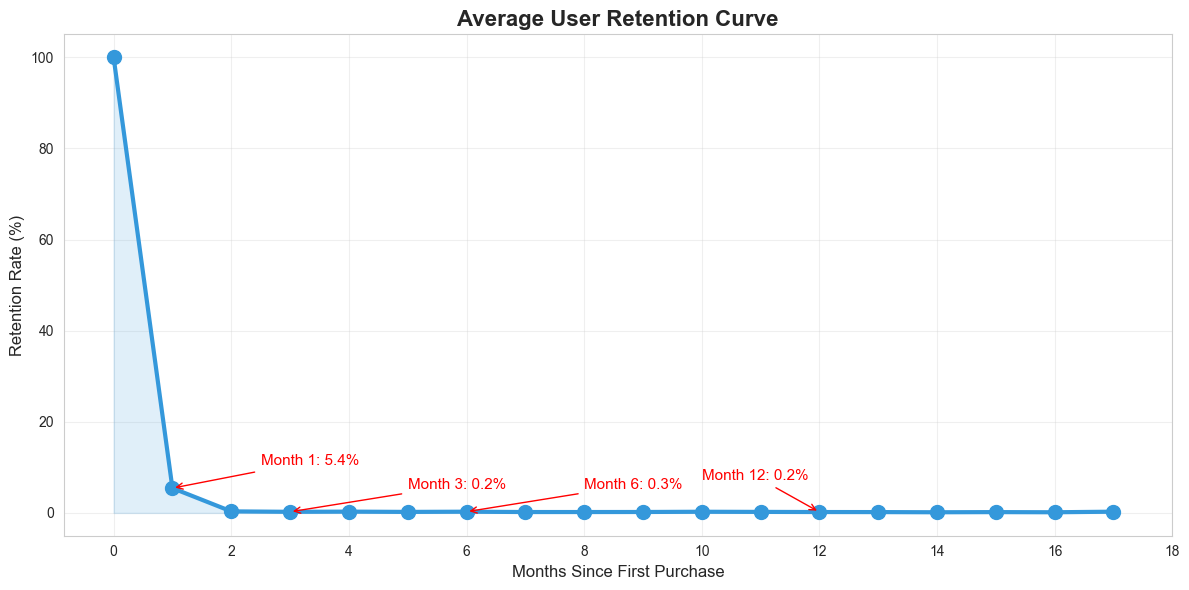

In [4]:
# Average retention curve
avg_retention = retention_matrix.mean(axis=0)
print('Average Retention by Month Offset:')
for month, pct in avg_retention.items():
    if month <= 12:
        print(f'  Month {int(month):>2}: {pct:.1f}%')

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
months = avg_retention.index[:18]
values = avg_retention.values[:18]

ax.plot(months, values, marker='o', linewidth=3, markersize=10, color='#3498db')
ax.fill_between(months, values, alpha=0.15, color='#3498db')
ax.set_xlabel('Months Since First Purchase', fontsize=12)
ax.set_ylabel('Retention Rate (%)', fontsize=12)
ax.set_title('Average User Retention Curve', fontsize=16, fontweight='bold')
ax.set_xticks(range(0, 19, 2))

# Annotate key points
ax.annotate(f'Month 1: {values[1]:.1f}%', xy=(1, values[1]), xytext=(2.5, values[1]+5),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=11, color='red')
ax.annotate(f'Month 3: {values[3]:.1f}%', xy=(3, values[3]), xytext=(5, values[3]+5),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=11, color='red')
ax.annotate(f'Month 6: {values[6]:.1f}%', xy=(6, values[6]), xytext=(8, values[6]+5),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=11, color='red')
ax.annotate(f'Month 12: {values[12]:.1f}%', xy=(12, values[12]), xytext=(10, values[12]+7),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=11, color='red')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../output/retention_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 复购行为分析

Repeat purchase rate (users with >=2 orders): 3.0%

Order frequency distribution:
  1 order(s): 90,557 users (97.0%)
  2 order(s):  2,573 users (2.8%)
  3 order(s):    181 users (0.2%)
  4 order(s):     28 users (0.0%)
  5 order(s):      9 users (0.0%)
  6 order(s):      5 users (0.0%)
  7 order(s):      3 users (0.0%)
  9 order(s):      1 users (0.0%)
  15 order(s):      1 users (0.0%)

Time to Second Purchase:
count    2801.000000
mean       80.844698
std       109.899443
min         0.000000
25%         0.000000
50%        28.000000
75%       126.000000
max       608.000000
Name: days_to_2nd, dtype: float64


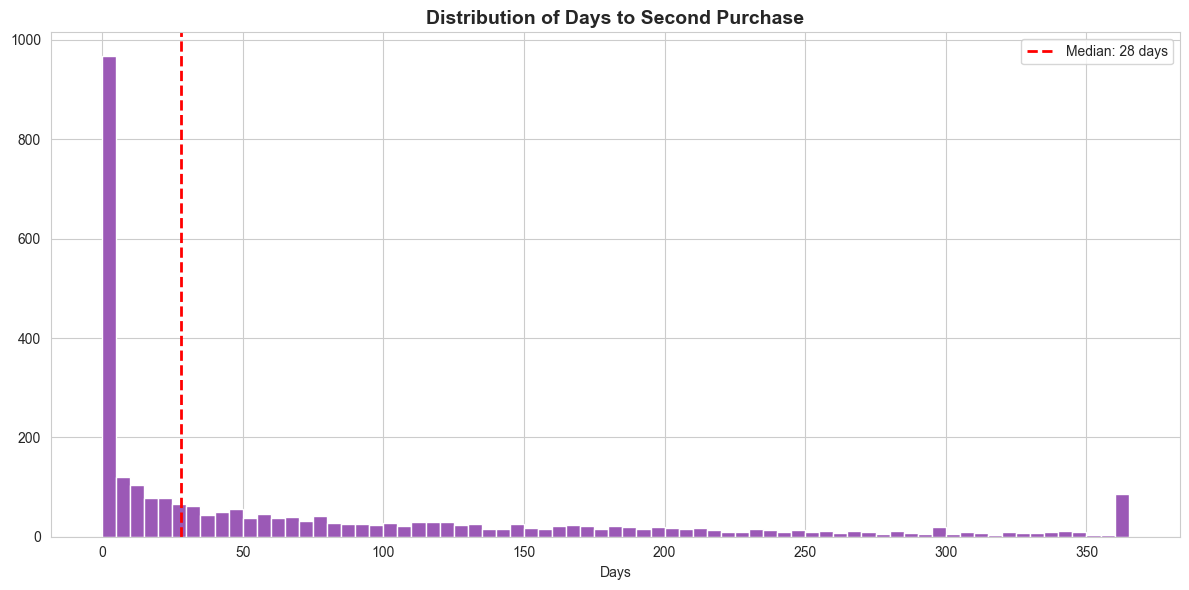

In [5]:
# Repeat purchase rate
orders_per_user = user_orders.groupby('customer_unique_id')['order_id'].nunique()
repeat_rate = (orders_per_user > 1).mean() * 100
print(f'Repeat purchase rate (users with >=2 orders): {repeat_rate:.1f}%')
print(f'\nOrder frequency distribution:')
freq_dist = orders_per_user.value_counts().sort_index()
for orders, users in freq_dist.head(10).items():
    print(f'  {orders} order(s): {users:>6,} users ({users/len(orders_per_user)*100:.1f}%)')

# Time to second purchase
user_order_dates = user_orders.groupby('customer_unique_id')['purchase_date'].apply(list).reset_index()
user_order_dates['n_orders'] = user_order_dates['purchase_date'].apply(len)
repeat_buyers = user_order_dates[user_order_dates['n_orders'] > 1].copy()

def days_to_second(dates):
    sorted_dates = sorted(dates)
    return (sorted_dates[1] - sorted_dates[0]).days

repeat_buyers['days_to_2nd'] = repeat_buyers['purchase_date'].apply(days_to_second)

print(f'\nTime to Second Purchase:')
print(repeat_buyers['days_to_2nd'].describe())

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(repeat_buyers['days_to_2nd'].clip(0, 365), bins=73, color='#9b59b6', edgecolor='white')
ax.axvline(repeat_buyers['days_to_2nd'].median(), color='red', linestyle='--',
           linewidth=2, label=f'Median: {repeat_buyers["days_to_2nd"].median():.0f} days')
ax.set_title('Distribution of Days to Second Purchase', fontsize=14, fontweight='bold')
ax.set_xlabel('Days')
ax.legend()
plt.tight_layout()
plt.savefig('../output/days_to_second_purchase.png', dpi=150, bbox_inches='tight')
plt.show()